# Parameter tuning Narrabeen

## Paths and settings

In [1]:
new_initial_state = False
new_tuning = False

In [2]:
path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
# path_to_data_folder = '/home/jovyan/data/98_paper2_kf_dtm/'

# paths jupyter utwente
path_tc = path_to_data_folder + '01_tides/output/'
path_validation = path_to_data_folder + '03_Narrabeen_validation_data/'

path_input_general = path_to_data_folder + '0_input_general/'
path_input = path_to_data_folder + '32_33_Narrabeen_DEM/input/'
path_output = path_to_data_folder + '32_33_Narrabeen_DEM/output/'
path_altimetry_output = path_to_data_folder + '31_Narra_altimetry/output/'

# filename for gebco
fn_gebco = 'gebco_2024_n-33.6_s-33.8_w151.2_e151.4.nc'

epsg = 4326 # WGS84
epsg_local = 32356

year_start = 1993
year_end = 2020 # included
num_years_per_bin = 1

import warnings
warnings.filterwarnings("ignore")

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import time
import itertools

from scipy import stats
from scipy.sparse import diags_array

from shapely import LineString

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colormaps as cm
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_visualisation
import P2_functions

In [4]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Static parameters

In [5]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Observations

In [6]:
# Altimetry
fn = 'tp_plus_ales_epsg32356.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [7]:
# Tidal correction
fn = 'tides_narra.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

In [8]:
# Cassie shorelines
folders = ['2_1992-09-24_1998-04-18_spac100_ext400_thresh0/',
          '3_1998-05-20_2007-09-18_spac100_ext400_thresh0/',
          '4_2007-10-04_2016-10-28_spac100_ext400_thresh0/',
          '5_2016-11-13_2021-10-26_spac100_ext400_thresh0/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

263 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 115 points (min: 34, max: 143).


### Shoreline outlier rejection

In [9]:
med_sl = CD_geometry.median_shoreline_from_transect_intersections(c_shorelines, spacing=50, transect_length=5000, smooth_factor=10)
t_factor = 2 # threshold = t_factor * mean, (mean of distances to reference shoreline), points inside that range are kept
c_shorelines_corr = CD_geometry.shoreline_outlier_rejection(c_shorelines, med_sl, epsg, t_factor)
pickle.dump(c_shorelines_corr, open(path_output + 'c_shorelines_corr.pkl', 'wb'))

12.0% of shoreline points were discarded.


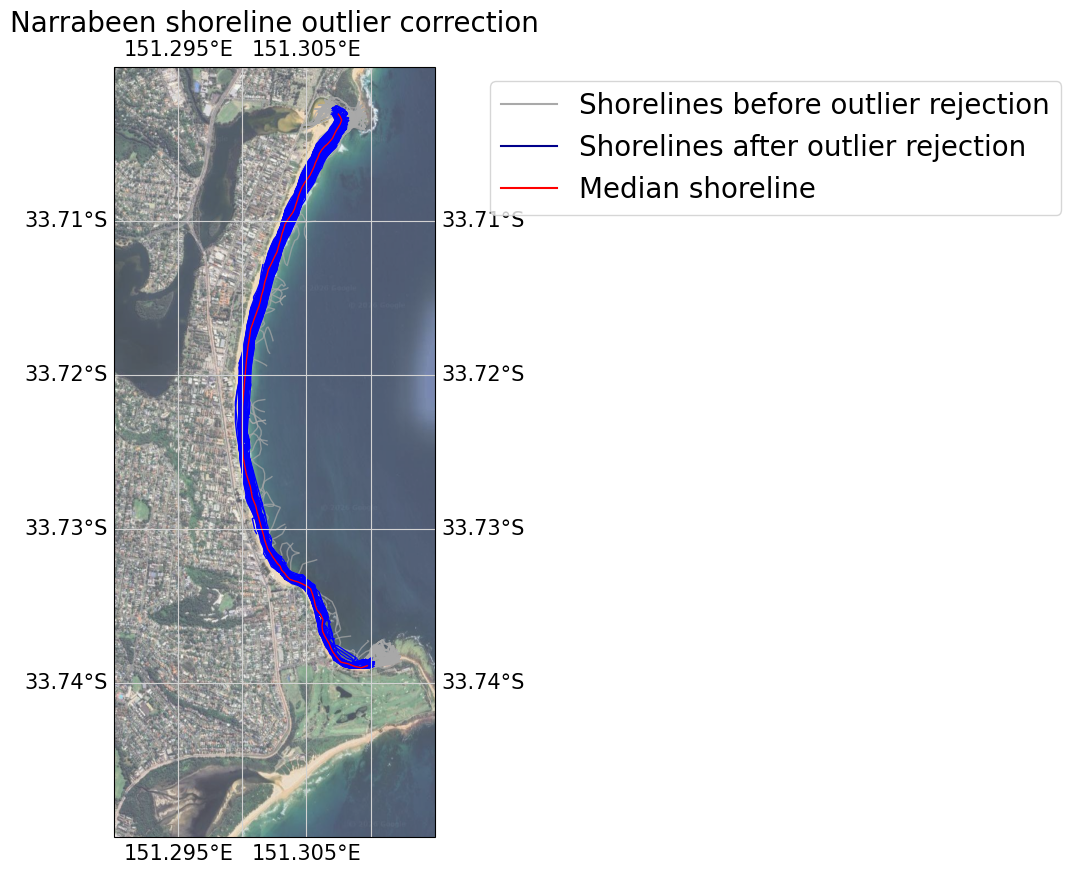

In [24]:
# Visual inspection of shoreline outlier rejection
projection = ccrs.PlateCarree()
extent = [151.29, 151.315, -33.75, -33.70]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

ax.add_geometries(med_sl, crs=projection, facecolor='none', edgecolor='red')

for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='darkgrey', zorder=1, alpha=.7)
for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='blue', zorder=1, alpha=1)

ax.set_title('Narrabeen shoreline outlier correction')

legend_elements = [
Line2D([0], [0], color='darkgrey', label='Shorelines before outlier rejection'),
Line2D([0], [0], color='darkblue', label='Shorelines after outlier rejection'),
Line2D([0], [0], color='red', label='Median shoreline'),
]
ax.legend(handles=legend_elements, bbox_to_anchor=(3,1))

plt.savefig(f'{path_output}Narrabeen_shoreline_outlier_rejection.png', dpi=300, bbox_inches='tight')

## Validation data

In [11]:
vali_gdf_orig = gpd.read_file(path_validation + 'narrabeen_profiles_with_coords.geojson')
vali_gdf_orig = vali_gdf_orig.set_index('date')

# Reduce to time after 1993
idx, = np.where(vali_gdf_orig.index.year >= year_start)
vali_gdf_orig = vali_gdf_orig.iloc[idx]

# yearly means anchored in June
# https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
vali_df_mean = vali_gdf_orig.drop(columns=['profile']).groupby([pd.Grouper(freq='YE-JUN'), 'geometry']).mean()

vali_years = vali_df_mean.reset_index('geometry').index.year
vali_df_mean = vali_df_mean.droplevel(0).reset_index()
vali_df_mean.index = vali_years

# Change format so that years are the columns and rows the unique point geometries
# (that format is expected by the compute_volume function)
vali_df = vali_df_mean.pivot_table(index='geometry', columns='date', values='elev', aggfunc='first')
vali_df = vali_df.reset_index()
vali_gdf = gpd.GeoDataFrame(vali_df, geometry='geometry')

vali_gdf.columns = [str(_) for _ in vali_gdf.columns]
vali_gdf = vali_gdf.drop(columns=['2000', '2001', '2002', '2012'], errors='ignore') # no Cassie shorelines available in these years

vali_gdf.to_file(path_output + 'narra_vali_gdf.geojson')

### Map

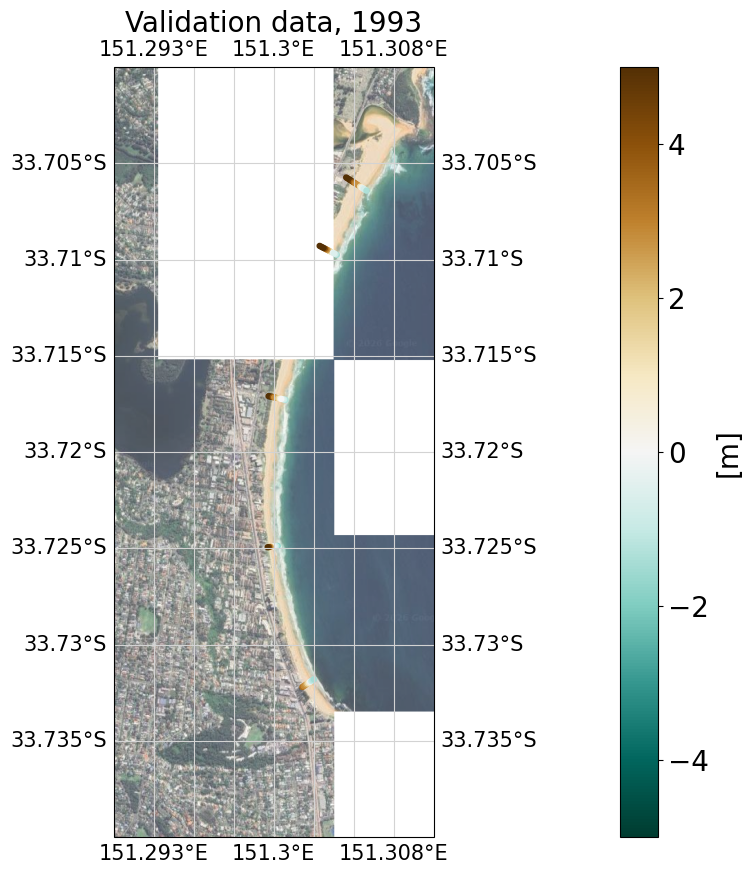

In [12]:
year = '1993'

extent = [151.29, 151.31, -33.74, -33.70]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

plot = ax.scatter(vali_gdf.geometry.x, vali_gdf.geometry.y, c=vali_gdf[year],
                  transform=ccrs.PlateCarree(), marker='.', s=50, cmap='BrBG_r', vmin=-5, vmax=5)
fig.colorbar(plot, shrink=1, pad=0.12, label='[m]')
ax.set_title(f'Validation data, {year}');

## Initial state

In [13]:
resolution = CD_geometry.dist_meter_to_dist_deg(50) # [deg], resolution of the target grid in x- and y-direction
fn_init = f'init_{epsg}_resolution_50m.tif'
if (not os.path.isfile(path_output + fn_init)) | new_initial_state:
    # Target area: polgon around the shorelines
    poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=1000, buffer_size=resolution)
    pickle.dump(poly_sl_corr, open(path_output + f'poly_sl_corr{epsg}.pkl', 'wb'))

    # Initial state
    CD_kalman.initial_state(poly_sl_corr, med_sl, epsg, resolution, alt,
                            path_input+'2_global_DEMs/', path_output, fn_init, fn_gebco)
else:
    poly_sl_corr = pickle.load(open(path_output + f'poly_sl_corr{epsg}.pkl', 'rb'))

Always load `init`, even if it was computed in this go (otherwise there is one case where init is a dataframe, and one case where it is an xarray DataSet):

In [14]:
init = xr.open_dataset(path_output+fn_init).squeeze()

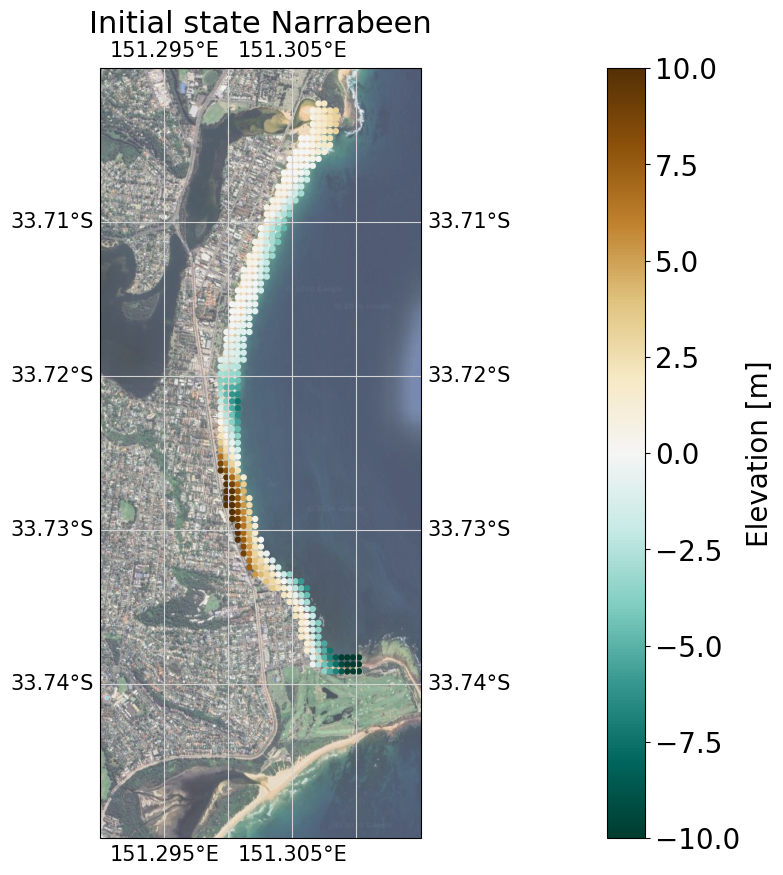

In [17]:
# Plot intial state
init_df = init.to_dataframe().dropna()
x = init_df.index.get_level_values('x')
y = init_df.index.get_level_values('y')

projection = ccrs.PlateCarree()
extent = [151.29, 151.315, -33.75, -33.70]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

# for sl in c_shorelines:
#     ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='brown', zorder=1, alpha=.7)
    
# ax.add_geometries(poly_sl_corr, crs=projection, facecolor='none', edgecolor='black')
# ax.add_geometries(med_sl, crs=projection, facecolor='none', edgecolor='blue')
    
plot = ax.scatter(x, y, c=init_df.band_data, transform=projection, marker='.', s=50,
                  cmap='BrBG_r', vmin=-10, vmax=10)

# Validation data
# ax.scatter(vali_gdf.geometry.x, vali_gdf.geometry.y, c='blue', transform=ccrs.PlateCarree(), marker='.', s=50)

fig.colorbar(plot, shrink=1, pad=0.12, label='Elevation [m]')
ax.set_title('Initial state Narrabeen', fontsize=22);

plt.savefig(f'{path_output}Narra_initial_state.png', dpi=300, bbox_inches='tight')

## Define area for volume change

### Buffer around the profiles

In [16]:
if not os.path.isfile(path_output + 'profile_polys.pkl'):
    profile_polys = {}
    profile_names = np.unique(vali_gdf_orig['profile'])
    for profile in profile_names:
        idx_pf, = np.where(vali_gdf_orig['profile'] == profile)
        vali_pf = vali_gdf_orig.iloc[idx_pf]

        pf = LineString(vali_pf.geometry)
        bs = CD_geometry.dist_meter_to_dist_deg(50) # buffer size
        profile_polys[profile] = pf.buffer(bs)

    pickle.dump(profile_polys, open(path_output + 'profile_polys.pkl', 'wb'))
else:
    profile_polys = pickle.load(open(path_output + 'profile_polys.pkl', 'rb'))

In [17]:
# Reduce profile polys to shoreline area
profile_polys_red = {}
for profile in profile_polys.keys():
    profile_polys_red[profile] = profile_polys[profile].intersection(poly_sl_corr)

pickle.dump(profile_polys_red, open(path_output + 'profile_polys_red.pkl', 'wb'))

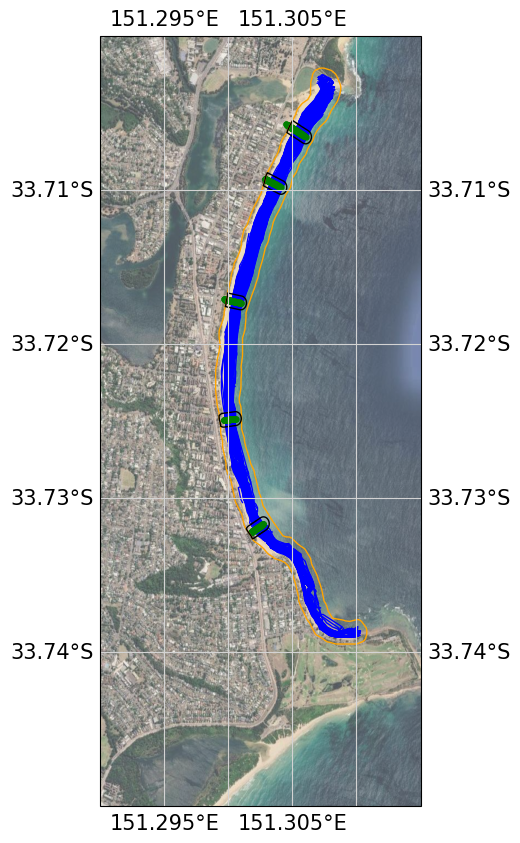

In [18]:
# Visualise volume change areas
projection = ccrs.PlateCarree()
extent = [151.29, 151.315, -33.75, -33.70]
# extent = [151.29, 151.315, -33.71, -33.70] # zoom to profile 1
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

ax.add_geometries(poly_sl_corr, crs=projection, facecolor='none', edgecolor='orange')

ax.add_geometries(profile_polys_red['PF1'], crs=projection, facecolor='none', edgecolor='black')
ax.add_geometries(profile_polys_red['PF2'], crs=projection, facecolor='none', edgecolor='black')
ax.add_geometries(profile_polys_red['PF4'], crs=projection, facecolor='none', edgecolor='black')
ax.add_geometries(profile_polys_red['PF6'], crs=projection, facecolor='none', edgecolor='black')
ax.add_geometries(profile_polys_red['PF8'], crs=projection, facecolor='none', edgecolor='black')

for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='blue', zorder=1, alpha=1)
    
# Validation data
ax.scatter(vali_gdf.geometry.x, vali_gdf.geometry.y, c='green',
                transform=ccrs.PlateCarree(), marker='.', s=50)

## Tune

### Parameters

In [19]:
# sigma_l
# Minimum combined error
beach_slope_min = 0.001
rmse_h_cassie_min = 5
std_alt_min = 0.03
rms_eot20_min = 0.01 # from paper, table 3: 0.061
sigma_v_total_min = np.sqrt((beach_slope_min * rmse_h_cassie_min)**2 + std_alt_min**2 + rms_eot20_min**2)

# Maximum combined error
beach_slope_max = 0.02
rmse_h_cassie_max = 50
std_alt_max = .8
rms_eot20_max = 0.1
sigma_v_total_max = np.sqrt((beach_slope_max * rmse_h_cassie_max)**2 + std_alt_max**2 + rms_eot20_max**2)

print(f'Min: {round(sigma_v_total_min,2)} m, Max: {round(sigma_v_total_max,2)} m')

Min: 0.03 m, Max: 1.28 m


In [20]:
sigma_l_values =  np.linspace(sigma_v_total_min, sigma_v_total_max, 5) # [m]
factors = [1, 10, 25]
std_init_values = [1, 3, 9] # [m]

param_df = pd.DataFrame(list(itertools.product(factors, sigma_l_values, std_init_values)), columns=['factor', 'sigma_l', 'std_init'])

param_df['sigma_q'] = param_df['factor'] * param_df['sigma_l']
param_df

,factor,sigma_l,std_init,sigma_q
0,1,0.032016,1,0.032016
1,1,0.032016,3,0.032016
2,1,0.032016,9,0.032016
3,1,0.345143,1,0.345143
4,1,0.345143,3,0.345143
5,1,0.345143,9,0.345143
6,1,0.658269,1,0.658269
7,1,0.658269,3,0.658269
8,1,0.658269,9,0.658269
9,1,0.971396,1,0.971396


### Get beach slope from validation data

In [21]:
all_slopes = np.empty(0)
profile_names = np.unique(vali_gdf_orig['profile'])
for profile in profile_names:
    idx_pf, = np.where(vali_gdf_orig['profile'] == profile)
    vali_pf = vali_gdf_orig.iloc[idx_pf]

    slopes_averaged = vali_pf.slope.groupby(pd.Grouper(freq='YE')).mean().values
    all_slopes = np.concatenate([all_slopes, slopes_averaged])

In [22]:
print('Beach slope statistics (all_slopes contains one average beach slope per profile and per year, so the mean of one measurement line)')
print(f'Mean beach slope: {np.nanmean(all_slopes)}')
print(f'Median beach slope: {np.nanmedian(all_slopes)}')
print(f'Minimum beach slope: {np.nanmin(np.abs(all_slopes))}')
print(f'Maximum beach slope: {np.nanmax(np.abs(all_slopes))}')

Beach slope statistics (all_slopes contains one average beach slope per profile and per year, so the mean of one measurement line)
Mean beach slope: 0.10362933806648474
Median beach slope: 0.10498019801980198
Minimum beach slope: 0.045512820512820504
Maximum beach slope: 0.20732235294117646


### Loop

In [23]:
if new_tuning:
    year_ref = 2006
    n_iter = 2
    
    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m]
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]

    # Store statistics for volume time series in DataFrames
    rmse_df = pd.DataFrame()
    corr_df = pd.DataFrame()
    pvalues_df = pd.DataFrame()
    trend_df = pd.DataFrame()
    errors_df = pd.DataFrame()
    
    for i in param_df.index:
        factor = param_df.loc[i, 'factor']
        sigma_q = param_df.loc[i, 'sigma_q']
        sigma_l = param_df.loc[i, 'sigma_l']
        std_init = param_df.loc[i, 'std_init']
        print(f'{i}: factor = {factor}, sigma_l = {sigma_l}, std_init = {std_init}')

                # Initialise state vector
        init_df = init.to_dataframe().dropna()
        x = init_df.index.get_level_values('x')
        y = init_df.index.get_level_values('y')    
        x_state = gpd.GeoDataFrame({'init': init_df.band_data.values}, geometry=gpd.points_from_xy(x, y))
        x_state = x_state.set_crs(epsg)

        # Covariance matrix of the initial state
        sigma_xx_init_df = gpd.GeoDataFrame({'sigma': std_init**2}, geometry=x_state.geometry, index=x_state.index)
        sigma_xx_init = diags_array(sigma_xx_init_df.sigma)

        # "Iteration 0"
        x_k = x_state['init'].copy()
        sigma_xx_k = sigma_xx_init

        # Initial trend 
        trends = gpd.GeoDataFrame({'trend_k':np.full(len(init_df.index), 0)}, geometry=x_state.geometry)

        for j in range(0, n_iter):
            x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(
                  x_state, init, x_k, sigma_xx_k, year_start, year_end, num_years_per_bin, rs_shoreline,
                  seg_length, alt, tidal_corr, epsg, epsg_local, T_is_identity, max_distance, w_id,
                  max_noupdate, std_pseudobs, sigma_l, sigma_q, eps_factor, trends['trend_k'].copy(), year_ref)

            # New trend
            trends[f'trend_{j}'] = CD_kalman.compute_trend_in_each_gridpoint(x_state)   
            # Overwrite  trend_k for next iteration
            trends['trend_k'] = trends[f'trend_{j}'].copy()

            # Overwrite x_k so that next iteration starts with residuals and not the full signal
            x_k = x_state.iloc[:,-1].copy() # last entry is x_up_2020 (or whatever end_year is specified)
            sigma_xx_k = sigma_xx_up[list(sigma_xx_up)[-1]] # unordered dict, but should also access end_year

        x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, T, eps_factor)

        # Re-add trend
        x_state_readd = x_state.copy()
        x_state_s_readd = x_state_s.copy()

        all_trends = trends.drop(columns=['geometry', 'trend_k']+[col for col in trends.columns if col.startswith('mean_')])
        trend_sum = all_trends.cumsum(axis=1).iloc[:,-2] # second last column, because last trend was not subtracted

        year_list = [int(col.split('_')[-1]) for col in x_state.columns if col.startswith('x_up_')]
        for year in year_list:
            deltaYear = year - year_ref
            x_state_readd[f'x_up_{year}'] += trend_sum * deltaYear
            x_state_readd[f'x_pred_{year}'] += trend_sum * deltaYear
            x_state_s_readd[f'x_s_{year}'] += trend_sum * deltaYear

        kf_interp, rts_interp = CD_kalman.interpolate_results(vali_gdf, x_state_readd, x_state_s_readd)

        # Volume change time series
        volumes_vali, volumes_kf, volumes_rts = P2_functions.get_all_volumes(vali_gdf, kf_interp, rts_interp, profile_polys, epsg_local)
        # trends, trend_diff_perc, corr, pvalues, rmse, rmse_perc = P2_functions.volume_stats_Narrabeen(volumes_vali, volumes_kf, volumes_rts, profile_polys_red, print_output=False)
        trends, trend_diff_perc, corr, pvalues, rmse, rmse_perc = P2_functions.volume_stats_averaged(volumes_vali, volumes_kf, volumes_rts, print_output=False)
        
        rmse_df[i] = pd.DataFrame([rmse]).T[0]
        corr_df[i] = pd.DataFrame([corr]).T[0]
        pvalues_df[i] = pd.DataFrame([pvalues]).T[0]
        trend_df[i] = pd.DataFrame([trends]).T[0]

    rmse_df.to_pickle(path_output+'partun_volumes_rmse.pkl')
    corr_df.to_pickle(path_output+'partun_volumes_corr.pkl')
    pvalues_df.to_pickle(path_output+'partun_volumes_pvalues.pkl')
    trend_df.to_pickle(path_output+'partun_volumes_trends.pkl')
        
else:
    rmse_df = pd.read_pickle(path_output+'partun_volumes_rmse.pkl')
    corr_df = pd.read_pickle(path_output+'partun_volumes_corr.pkl')
    pvalues_df = pd.read_pickle(path_output+'partun_volumes_pvalues.pkl')
    trend_df = pd.read_pickle(path_output+'partun_volumes_trends.pkl')
    print("Loaded files.")

    all_stats = xr.open_dataset(f'{path_output}partun_elevs_all_stats.nc')
    print(f'Loaded {path_output}partun_elevs_all_stats.nc')
    

0: factor = 1, sigma_l = 0.032015621187164243, std_init = 1
Forward run done. Needed  25.6 seconds.
Forward run done. Needed  27.6 seconds.
Backward run done. Needed  6.5 seconds.
Interpolation done. Needed  0.3 seconds.
1: factor = 1, sigma_l = 0.032015621187164243, std_init = 3
Forward run done. Needed  26.0 seconds.
Forward run done. Needed  26.7 seconds.
Backward run done. Needed  6.6 seconds.
Interpolation done. Needed  0.2 seconds.
2: factor = 1, sigma_l = 0.032015621187164243, std_init = 9
Forward run done. Needed  24.2 seconds.
Forward run done. Needed  25.6 seconds.
Backward run done. Needed  6.4 seconds.
Interpolation done. Needed  0.2 seconds.
3: factor = 1, sigma_l = 0.3451425303570014, std_init = 1
Forward run done. Needed  22.9 seconds.
Forward run done. Needed  24.8 seconds.
Backward run done. Needed  6.0 seconds.
Interpolation done. Needed  0.2 seconds.
4: factor = 1, sigma_l = 0.3451425303570014, std_init = 3
Forward run done. Needed  23.2 seconds.
Forward run done. Ne

## Plots

In [24]:
cmap = cm['Blues_r']
c_list = cmap(np.linspace(0,.6,3))
ls_list = ['-', '-.', ':'] # encode sigma_init with linestyle

In [25]:
def plot_legend(ax, c_list, ls_list, factors, std_init_values):
    legend_elements = [
        Line2D([0], [0], color='none', label='$\\bf{Color: \\sigma_q}$', lw=0, ms=0),  # Subtitle
        
        Line2D([0], [0], color=c_list[0], label=f'$\\sigma_{{q}}$ = {factors[0]}$\\cdot \\sigma_{{obs}}$ m'),
        Line2D([0], [0], color=c_list[1], label=f'$\\sigma_{{q}}$ = {factors[1]}$\\cdot \\sigma_{{obs}}$ m'),
        Line2D([0], [0], color=c_list[2], label=f'$\\sigma_{{q}}$ = {factors[2]}$\\cdot \\sigma_{{obs}}$ m'),

        Line2D([0], [0], color='none', label='', lw=0, ms=0), # dummy for white space
        Line2D([0], [0], color='none', label='$\\bf{Linestyle: \\sigma_{{init}}}$', lw=0, ms=0),  # Subtitle

        Line2D([0], [0], color='grey', ls=ls_list[0], label=f'$\\sigma_{{init}}$ = {std_init_values[0]} m'),
        Line2D([0], [0], color='grey', ls=ls_list[1], label=f'$\\sigma_{{init}}$ = {std_init_values[1]} m'),
        Line2D([0], [0], color='grey', ls=ls_list[2], label=f'$\\sigma_{{init}}$ = {std_init_values[2]} m'),

        Line2D([0], [0], color='none', label='', lw=0, ms=0), # dummy for white space

        # Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1,1.1))

In [26]:
def plot_vol_stats(ax, data, ylabel, title, corr=False, plot_zero=False, ylim=None):
    for f, factor in enumerate(factors):
        for g, std_init in enumerate(std_init_values):
            idx, = np.where((param_df.factor == factor) & (param_df.std_init == std_init))
            ax.plot(param_df.loc[idx, 'sigma_l'], data.loc[idx], ls=ls_list[g], c=c_list[f], marker='.')
            
            if corr:
                pvalues_box = np.where(pvalues_df.T.loc[idx] < 0.05)[0]
                ax.plot(param_df.loc[idx[pvalues_box], 'sigma_l'], data.loc[idx[pvalues_box]].values,
                        marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
                ax.legend(handles=[Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')]) #, loc='lower right')

            if plot_zero:
                ax.axhline(y=0, color='grey')            

    if ylim != None:
        ax.set_ylim(ylim[0], ylim[1])

    # if not corr:
    #     ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        # ax.ticklabel_format(useOffset=False, style='plain')
    
    ax.set_xlabel(r'$\sigma_{l}$ [m]')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=22)
    ax.grid()

In [27]:
def mark_selected_param(ax, idx_selected, data):
    params_selected = param_df.iloc[idx_selected]
    ax.plot(params_selected['sigma_l'], data.iloc[idx_selected], 'o', c='None', markeredgecolor='red', ms=10, markeredgewidth=2)

#### Percentages

In [28]:
trend_diff_perc = pd.DataFrame(columns=['trend_diff_perc'], index=param_df.index)

trend_diff = trend_df.T['rts'] - trend_df.T['vali']
# Find the parameter combinations where both trends have the same sign
idx_pos, = np.where(np.sign(trend_df.T['rts']) == np.sign(trend_df.T['vali']))
idx_neg, = np.where(np.sign(trend_df.T['rts']) != np.sign(trend_df.T['vali']))

# Same sign: Quotient of absolute trends
trend_diff_perc.loc[idx_pos, 'trend_diff_perc'] = (np.abs(trend_diff.loc[idx_pos]) / np.abs(trend_df.T['vali'])) * 100
# Different sign: Trend diff perc should end up with negative sign
trend_diff_perc.loc[idx_neg, 'trend_diff_perc'] = (trend_diff.loc[idx_neg] / trend_df.T['vali']) * 100

In [29]:
rmse_perc = pd.DataFrame(columns=['rmse_perc'], index=param_df.index)
volumes_vali, volumes_kf, volumes_rts = P2_functions.get_all_volumes(vali_gdf, kf_interp, rts_interp, profile_polys, epsg_local)
rmse_perc = (np.abs(rmse_df.T)/np.abs(volumes_vali.mean().mean())) * 100

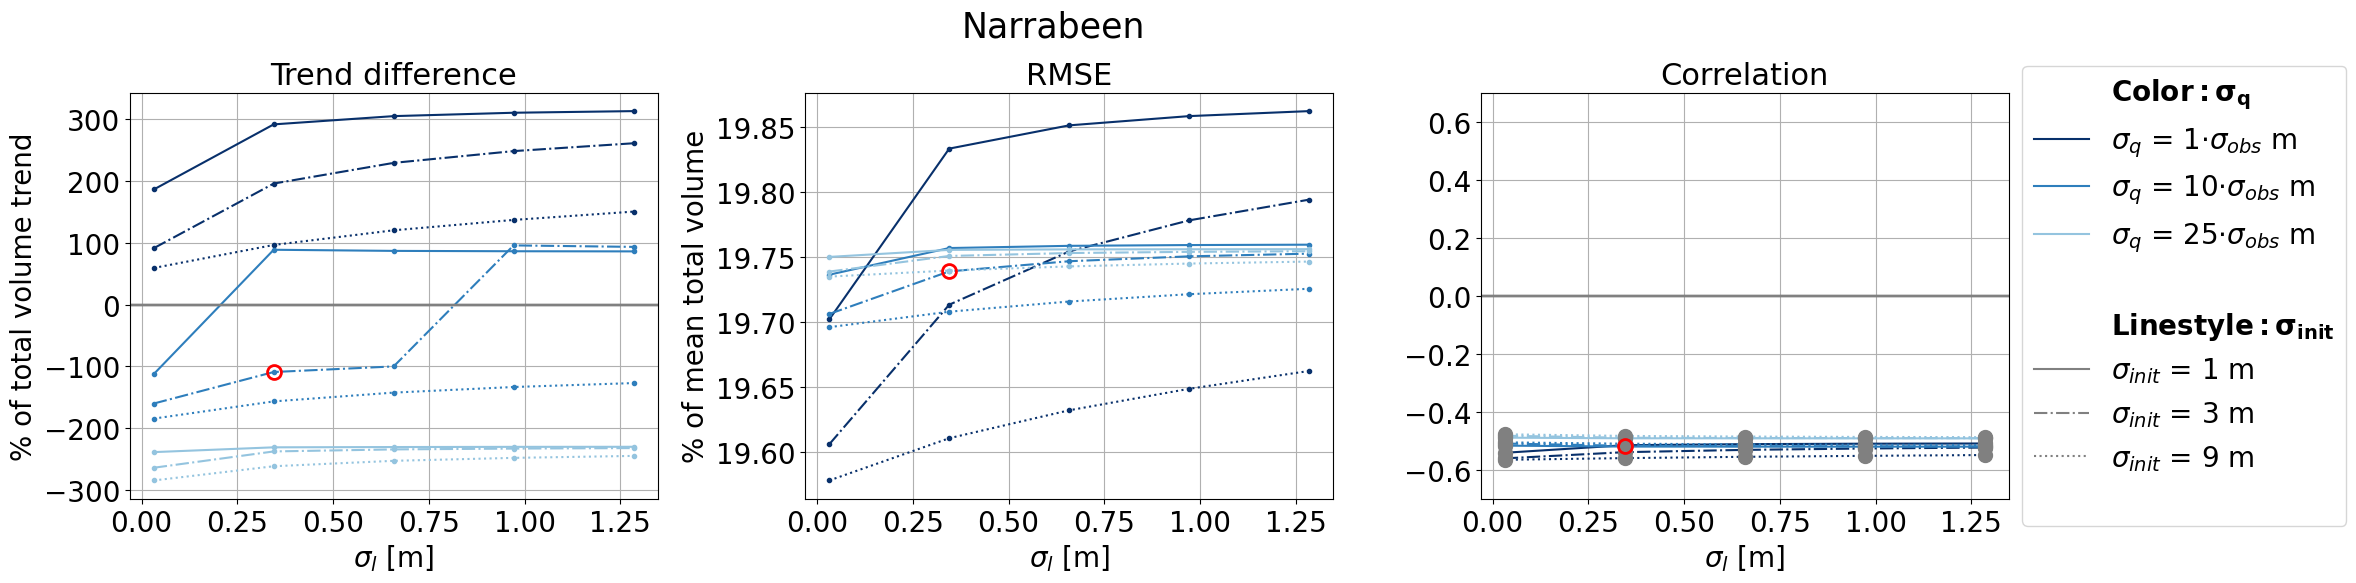

In [30]:
idx_selected = 19 # index of the parameters selected for validation

fig, axs = plt.subplots(1,3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.3, wspace=.28)

plot_vol_stats(axs[0], trend_diff_perc, ylabel='% of total volume trend', title='Trend difference', plot_zero=True)
mark_selected_param(axs[0], idx_selected, trend_diff_perc)

plot_vol_stats(axs[1], rmse_perc, ylabel='% of mean total volume', title='RMSE')
mark_selected_param(axs[1], idx_selected, rmse_perc)

ylim_corr = [-.7,.7]
plot_vol_stats(axs[2], corr_df.T, ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
mark_selected_param(axs[2], idx_selected, corr_df.T)

plot_legend(axs[2], c_list, ls_list, factors, std_init_values)
fig.suptitle('Narrabeen', y=1.1, fontsize=25);

plt.savefig(f'{path_output}Narra_partun.png', dpi=300, bbox_inches='tight')